In [258]:
# Chargement des dépendances pour le workflow de modelisation des emissions.
import pandas as pd
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from energy_sights.modeling.evaluate import plot_residuals, plot_features_importance, print_metrics, evaluate_regression, print_feature_importances
from energy_sights.modeling.train import ModelTrainer
from energy_sights.modeling.tuning import tune_model
from energy_sights.config import PROCESSED_DATA_DIR, target, MODELS_DIR
from energy_sights.logging_config import setup_logging
from energy_sights.preprocessing import nan_percent, numeric_describe
from energy_sights.plots import interactive_distribution
from energy_sights.preprocessing import logarithm
from importlib import reload
from energy_sights.modeling import tuning
from energy_sights import preprocessing
from notebooks.modeling_energy import features_name

In [256]:
reload(tuning)

<module 'energy_sights.modeling.tuning' from 'C:\\ML_projects\\energy_sights\\energy_sights\\modeling\\tuning.py'>

In [5]:
reload(preprocessing)

2026-02-18 22:39:31 | INFO     | energy_sights.preprocessing - Starting the Preprocessing
2026-02-18 22:39:31.561 | INFO     | energy_sights.preprocessing:<module>:12 - Starting the Preprocessing
2026-02-18 22:39:31 | SUCCESS  | energy_sights.preprocessing - End of the preprocessing
2026-02-18 22:39:31.570 | SUCCESS  | energy_sights.preprocessing:<module>:91 - End of the preprocessing


<module 'energy_sights.preprocessing' from 'C:\\ML_projects\\energy_sights\\energy_sights\\preprocessing.py'>

In [259]:
setup_logging()

In [260]:
data_path: Path = PROCESSED_DATA_DIR / 'processed_data.csv'

In [261]:
df = pd.read_csv(filepath_or_buffer=data_path)

In [262]:
df.head(n=5)

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,88434,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000
1,Hotel,103566,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453
2,Hotel,956110,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748
3,Hotel,61320,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000
4,Hotel,175580,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115


In [263]:
# Contrôle de la qualité des donnees.
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  1491 non-null   str    
 1   PropertyGFATotal     1491 non-null   int64  
 2   Neighborhood         1491 non-null   str    
 3   NumberofFloors       1491 non-null   int64  
 4   Latitude             1491 non-null   float64
 5   Longitude            1491 non-null   float64
 6   SiteEnergyUse(kBtu)  1491 non-null   float64
 7   TotalGHGEmissions    1491 non-null   float64
 8   IsComplex            1491 non-null   int64  
 9   BuildingAge          1491 non-null   int64  
 10  AverageFloorArea     1491 non-null   float64
 11  DistToCenter         1491 non-null   float64
 12  ParkingRatio         1491 non-null   float64
dtypes: float64(7), int64(4), str(2)
memory usage: 308.3 KB


In [264]:
nan_percent(df=df)

PrimaryPropertyType ->  0.0000 %

PropertyGFATotal ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofFloors ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0000 %

IsComplex ->  0.0000 %

BuildingAge ->  0.0000 %

AverageFloorArea ->  0.0000 %

DistToCenter ->  0.0000 %

ParkingRatio ->  0.0000 %



In [265]:
# Nouvelle analyse de la distribution de la cible.
interactive_distribution(df=df, col='TotalGHGEmissions')

In [266]:
numeric_describe(df=df, col='TotalGHGEmissions')

count     1491.000000
mean       193.594400
std        791.219842
min          0.400000
25%         20.395000
50%         49.580000
75%        146.965000
max      16870.980000
mode         6.300000
Name: TotalGHGEmissions, dtype: float64

## Filter for deletion of the outliers, to reduce the errors of the model

In [267]:
# q_90 = df['TotalGHGEmissions'].quantile(q=.90)

In [268]:
# final_df = df[df['TotalGHGEmissions'] < q_90]
# Suppression de ce filtrage pour cette iteration.
final_df = df.copy()

In [269]:
final_df.columns.tolist()

['PrimaryPropertyType',
 'PropertyGFATotal',
 'Neighborhood',
 'NumberofFloors',
 'Latitude',
 'Longitude',
 'SiteEnergyUse(kBtu)',
 'TotalGHGEmissions',
 'IsComplex',
 'BuildingAge',
 'AverageFloorArea',
 'DistToCenter',
 'ParkingRatio']

In [270]:
# Creation de nouvelles variables pour évaluer un gain de performance.
final_df = logarithm(df=final_df, col='PropertyGFATotal')

2026-02-18 23:46:01 | INFO     | energy_sights.preprocessing - The logarithm function has been used on PropertyGFATotal with success.
2026-02-18 23:46:01.894 | INFO     | energy_sights.preprocessing:logarithm:87 - The logarithm function has been used on PropertyGFATotal with success.


In [271]:
df.head()

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,88434,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000
1,Hotel,103566,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453
2,Hotel,956110,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748
3,Hotel,61320,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000
4,Hotel,175580,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115


In [272]:
# Creation de variables complémentaires.
final_df['IsModernBuilding'] = (final_df['BuildingAge'] <= 16).astype(dtype=int)

In [273]:
final_df.head(n=5)

,PrimaryPropertyType,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio,PropertyGFATotalLog,IsModernBuilding
0,Hotel,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000,11.390012,0
1,Hotel,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453,11.547964,0
2,Hotel,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748,13.770628,0
3,Hotel,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000,11.023861,0
4,Hotel,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115,12.075850,0


In [274]:
interactive_distribution(df=final_df, col='TotalGHGEmissions')

In [275]:
numeric_describe(df=final_df, col='TotalGHGEmissions')

count     1491.000000
mean       193.594400
std        791.219842
min          0.400000
25%         20.395000
50%         49.580000
75%        146.965000
max      16870.980000
mode         6.300000
Name: TotalGHGEmissions, dtype: float64

In [276]:
X = df.drop(columns=['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'])
y = df.filter(items=['TotalGHGEmissions'])

In [277]:
# Separation des donnees.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [278]:
X_train.columns.tolist()

['PrimaryPropertyType',
 'PropertyGFATotal',
 'Neighborhood',
 'NumberofFloors',
 'Latitude',
 'Longitude',
 'IsComplex',
 'BuildingAge',
 'AverageFloorArea',
 'DistToCenter',
 'ParkingRatio']

In [279]:
xgboost_trainer = ModelTrainer(model_type='xgboost')

In [280]:
base_model_boost = xgboost_trainer.build_pipeline(use_log_target=True)

2026-02-18 23:46:08 | INFO     | energy_sights.modeling.train - Model configuration with a logarithm transformation of the target .
2026-02-18 23:46:08.177 | INFO     | energy_sights.modeling.train:build_pipeline:85 - Model configuration with a logarithm transformation of the target .


In [281]:
# Recherche des meilleurs hyperparametres XGBoost sur la configuration initiale.
best_xgboost_model = tune_model(model=base_model_boost,
                                model_type='xgboost',
                                X_train=X_train,
                                y_train=y_train,
                                n_iter=40)

2026-02-18 23:46:09 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-18 23:46:09.036677
2026-02-18 23:46:09.036 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-18 23:46:09.036677
2026-02-18 23:46:09 | INFO     | energy_sights.modeling.tuning - Start of the training for xgboost
2026-02-18 23:46:09.040 | INFO     | energy_sights.modeling.tuning:tune_model:62 - Start of the training for xgboost
Fitting 5 folds for each of 40 candidates, totalling 200 fits
The best parameters finds are: {'regressor__model__subsample': 0.7, 'regressor__model__n_estimators': 500, 'regressor__model__min_child_weight': 1, 'regressor__model__max_depth': 6, 'regressor__model__learning_rate': 0.03, 'regressor__model__lambda': 3.0, 'regressor__model__gamma': 0, 'regressor__model__colsample_bytree': 0.7, 'regressor__model__alpha': 1.0}
The MAE on the train set:  51.09
The MAE on the validation set:  131.99
The best Score (RMSE roughly): 11.49


In [282]:
y_pred_train1 = best_xgboost_model.predict(X_train)

In [283]:
# Evaluation du modèle.
metrics_train1 = evaluate_regression(y_true=y_train, y_pred=y_pred_train1, model_name='xgboost')

In [284]:
print_metrics(metrics=metrics_train1)


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 353.44
  MAE  (Mean Absolute Error)     : 55.23
  MAPE (Error %)           : 32.67%
  R²   (Score explication)  : 0.7891


In [285]:
# Evaluation sur l'ensemble de test.
y_pred_test1 = best_xgboost_model.predict(X_test)

In [286]:
metrics_test1 = evaluate_regression(y_true=y_test, y_pred=y_pred_test1, model_name='xgboost')

In [287]:
print_metrics(metrics=metrics_test1)


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 757.07
  MAE  (Mean Absolute Error)     : 140.28
  MAPE (Error %)           : 146.89%
  R²   (Score explication)  : 0.2435


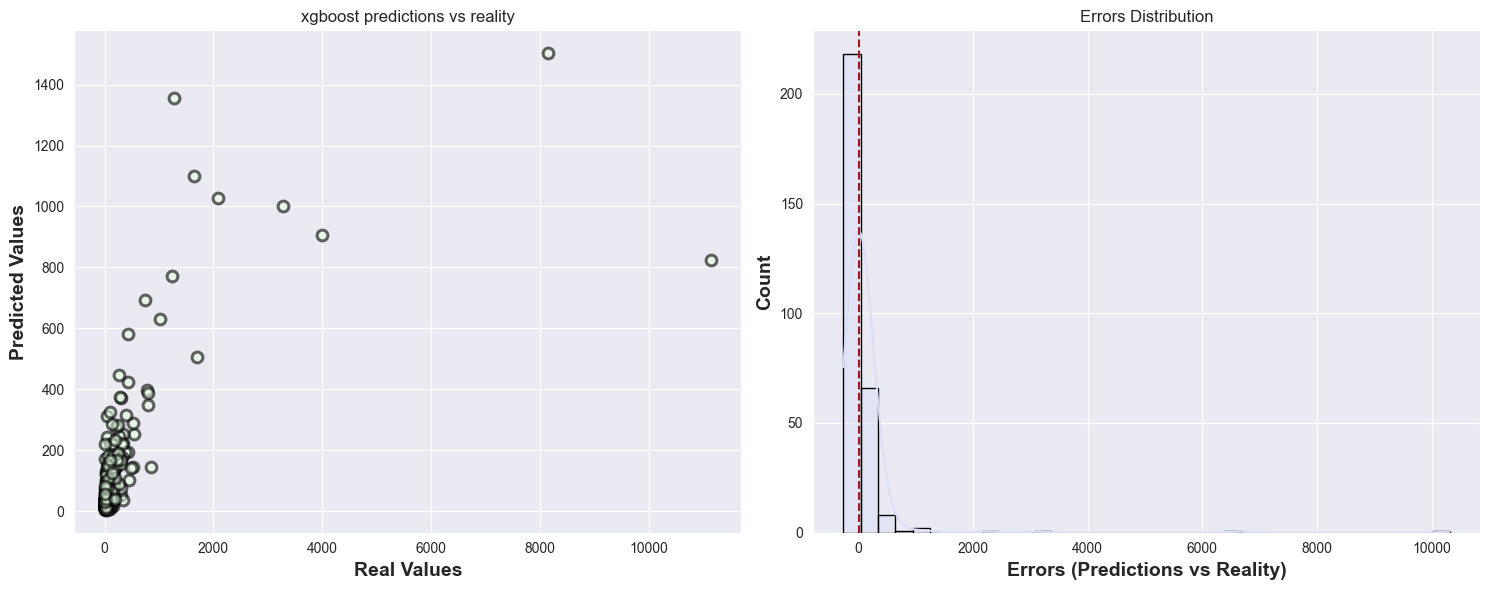

In [288]:
# Analyse des résidus.
plot_residuals(y_true=y_test,
               y_pred=y_pred_test1,
               model_name='xgboost')

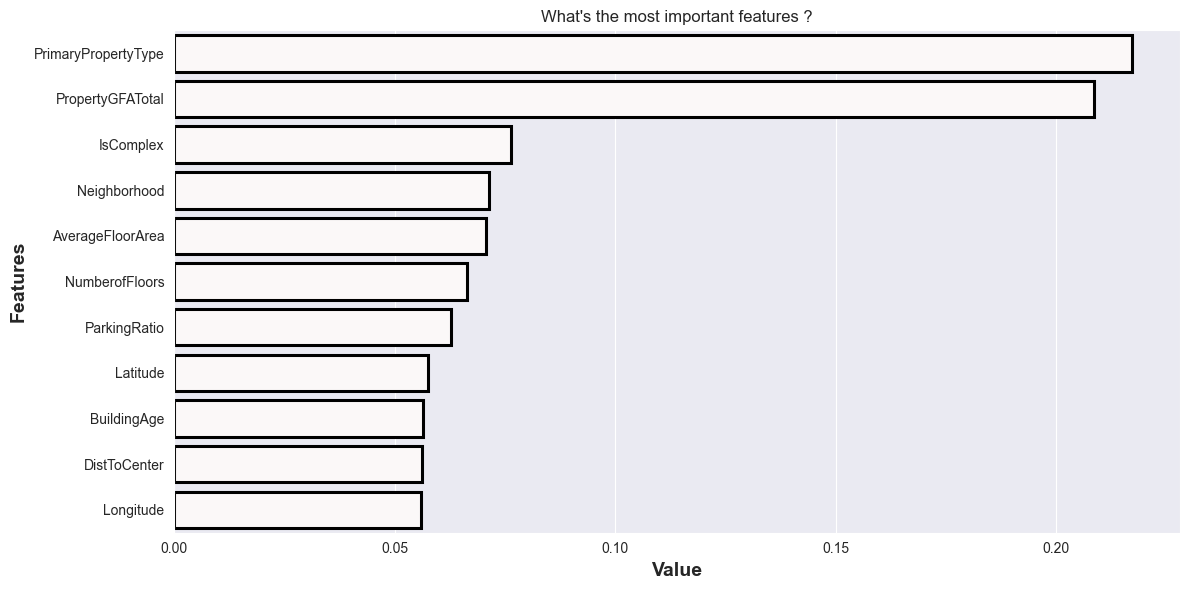

In [289]:
plot_features_importance(model=best_xgboost_model, feature_names=X_train.columns.tolist())

In [290]:
print_feature_importances(model=best_xgboost_model,
                          feature_names=X_train.columns.tolist())

,Features,Values
0,PrimaryPropertyType,0.217158
1,PropertyGFATotal,0.208609
6,IsComplex,0.076435
2,Neighborhood,0.071354
8,AverageFloorArea,0.070784
3,NumberofFloors,0.066462
10,ParkingRatio,0.062816
4,Latitude,0.057670
7,BuildingAge,0.056494
9,DistToCenter,0.056238


## We are dropping all the unnecessary columns

In [291]:
final_df.shape

(1491, 14)

In [292]:
final_df.head(n=5)

,PrimaryPropertyType,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio,PropertyGFATotalLog,IsModernBuilding
0,Hotel,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000,11.390012,0
1,Hotel,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453,11.547964,0
2,Hotel,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748,13.770628,0
3,Hotel,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000,11.023861,0
4,Hotel,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115,12.075850,0


In [293]:
# Filtrage des valeurs aberrantes de la cible.
q_95 = df['TotalGHGEmissions'].quantile(q=.95)

In [294]:
df = df[df['TotalGHGEmissions'] < q_95]

In [295]:
# Analyse de la distribution.
interactive_distribution(df=df, col='TotalGHGEmissions')

In [296]:
y_2 = df.filter(items=['TotalGHGEmissions'])

In [297]:
y_2.shape

(1416, 1)

In [377]:
# Constitution d'un jeu de variables epure pour renforcer la robustesse du modèle.
X_2 = df.drop(columns=['Latitude', 'Longitude',
                             'DistToCenter', 'IsComplex', 'ParkingRatio', 'NumberofFloors'] + target)

In [375]:
X_2.shape

(1416, 6)

In [378]:
X_2.head(n=5)

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,BuildingAge,AverageFloorArea
0,Hotel,88434,Downtown,89,7369.500000
1,Hotel,103566,Downtown,20,9415.090909
3,Hotel,61320,Downtown,90,6132.000000
4,Hotel,175580,Downtown,36,9754.444444
5,Other,97288,Downtown,17,48644.000000


In [300]:
# Chemin du modèle SiteEnergyUse(kBtu).
energy_model_path: Path = MODELS_DIR / 'energy_model.pkl'

In [301]:
# Utilisation du modèle precedent pour prédire SiteEnergyUse(kBtu) et enrichir l'apprentissage.
# Evaluation de l'apport de cette nouvelle variable.
energy_model_prod = joblib.load(filename=energy_model_path)

In [302]:
X_2.head()

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,IsComplex,BuildingAge,AverageFloorArea,ParkingRatio
0,Hotel,88434,Downtown,12,0,89,7369.500000,0.000000
1,Hotel,103566,Downtown,11,0,20,9415.090909,0.145453
3,Hotel,61320,Downtown,10,0,90,6132.000000,0.000000
4,Hotel,175580,Downtown,18,0,36,9754.444444,0.353115
5,Other,97288,Downtown,2,0,17,48644.000000,0.382349


In [380]:
X_2['SiteEnergyUse(kBtu)Predicted'] = energy_model_prod.predict(X_2)

In [381]:
X_2.shape

(1416, 6)

In [382]:
X_2.head(n=5)

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,BuildingAge,AverageFloorArea,SiteEnergyUse(kBtu)Predicted
0,Hotel,88434,Downtown,89,7369.500000,6.949170e+06
1,Hotel,103566,Downtown,20,9415.090909,8.764005e+06
3,Hotel,61320,Downtown,90,6132.000000,4.620115e+06
4,Hotel,175580,Downtown,36,9754.444444,1.380769e+07
5,Other,97288,Downtown,17,48644.000000,8.284170e+06


In [383]:
y_2.shape

(1416, 1)

In [384]:
# Separation des donnees pour entrainer un nouveau modèle.
X_train2, X_test2, y_train2, y_test2  = train_test_split(X_2, y_2, test_size=.2)

In [385]:
X_train2.shape

(1132, 6)

In [386]:
y_train2.shape

(1132, 1)

## Training without outliers and unnecessary columns

In [387]:
# Optimisation de XGBoost sur le jeu enrichi avec la prediction énergétique.
best_xgboost_model2 = tune_model(model=base_model_boost,
                                 X_train=X_train2,
                                 y_train=y_train2,
                                 model_type='xgboost',
                                 n_iter=35)

2026-02-19 00:09:51 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-19 00:09:51.421060
2026-02-19 00:09:51.421 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-19 00:09:51.421060
2026-02-19 00:09:51 | INFO     | energy_sights.modeling.tuning - Start of the training for xgboost
2026-02-19 00:09:51.424 | INFO     | energy_sights.modeling.tuning:tune_model:62 - Start of the training for xgboost
Fitting 5 folds for each of 35 candidates, totalling 175 fits
The best parameters finds are: {'regressor__model__subsample': 0.8, 'regressor__model__n_estimators': 300, 'regressor__model__min_child_weight': 5, 'regressor__model__max_depth': 6, 'regressor__model__learning_rate': 0.05, 'regressor__model__lambda': 2.0, 'regressor__model__gamma': 0.5, 'regressor__model__colsample_bytree': 0.7, 'regressor__model__alpha': 1.0}
The MAE on the train set:  35.09
The MAE on the validation set:  51.60
The best Score (RMSE roughly): 7.18


In [388]:
# Evaluation du modèle.
y_pred_train_filtered = best_xgboost_model2.predict(X_train2)

In [389]:
print_metrics(metrics=evaluate_regression(y_true=y_train2,
                                          y_pred=y_pred_train_filtered,
                                          model_name='xgboost'))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 64.99
  MAE  (Mean Absolute Error)     : 35.37
  MAPE (Error %)           : 52.48%
  R²   (Score explication)  : 0.6561


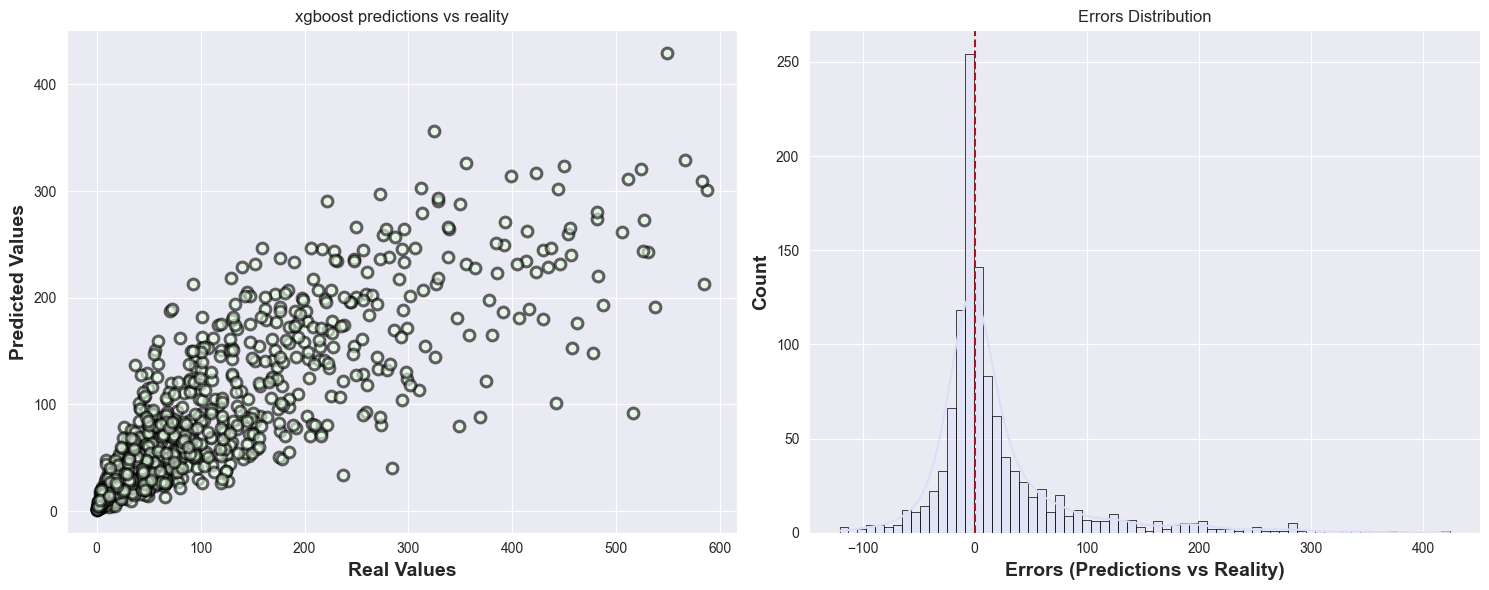

In [390]:
plot_residuals(y_true=y_train2, y_pred=y_pred_train_filtered, model_name='xgboost')

In [391]:
# Résultats sur l'ensemble de test.
y_pred_test_filtered = best_xgboost_model2.predict(X_test2)

In [392]:
print_metrics(metrics=evaluate_regression(y_true=y_test2, y_pred=y_pred_test_filtered, model_name='xgboost'))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 97.21
  MAE  (Mean Absolute Error)     : 58.23
  MAPE (Error %)           : 128.41%
  R²   (Score explication)  : 0.4497


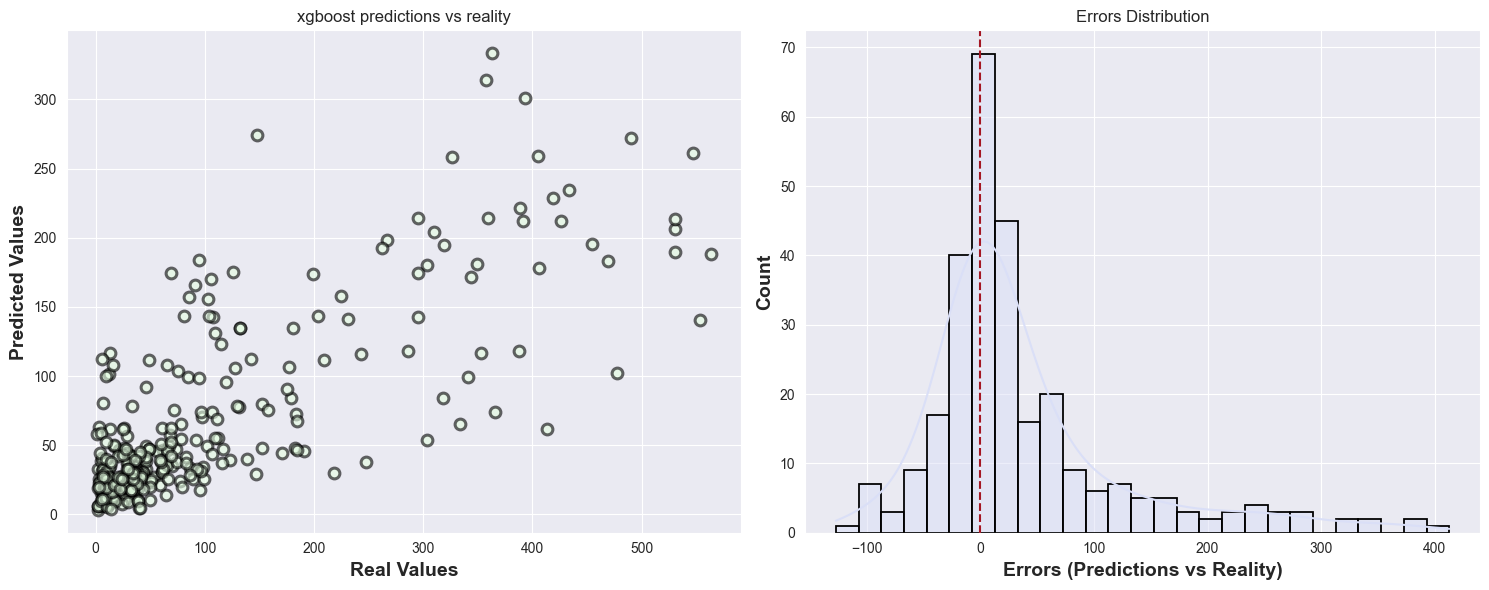

In [393]:
plot_residuals(y_true=y_test2, y_pred=y_pred_test_filtered, model_name='xgboost')

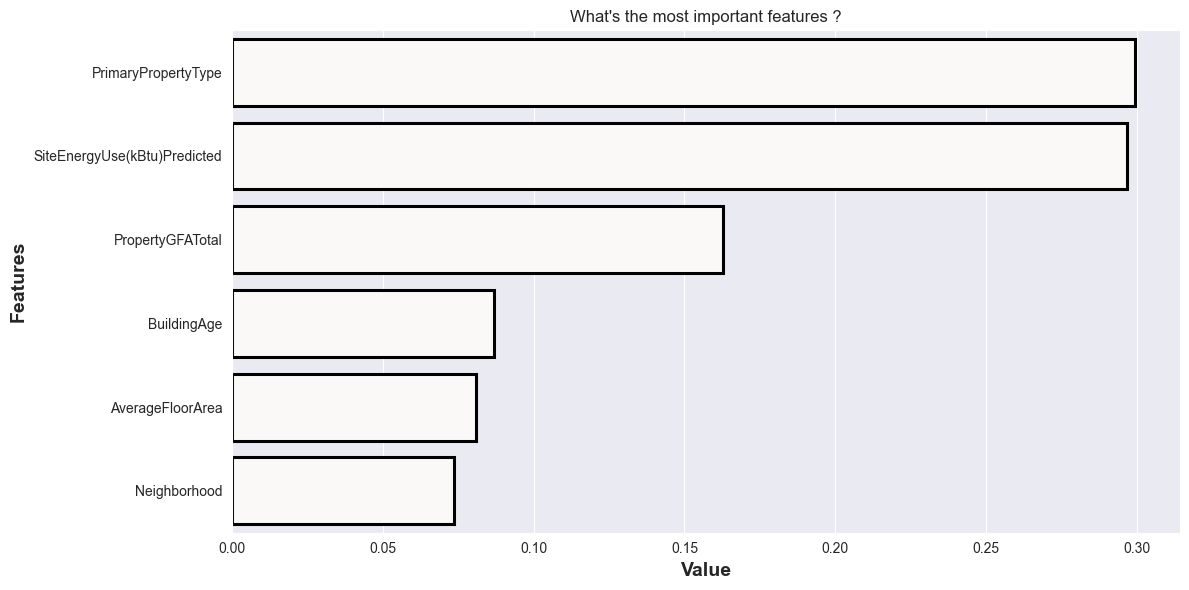

In [394]:
# Analyse de l'importance des variables.
plot_features_importance(model=best_xgboost_model2, feature_names=X_train2.columns.tolist())

In [395]:
print_feature_importances(model=best_xgboost_model2, feature_names=X_train2.columns.tolist())

,Features,Values
0,PrimaryPropertyType,0.299257
5,SiteEnergyUse(kBtu)Predicted,0.296741
1,PropertyGFATotal,0.162770
3,BuildingAge,0.086742
4,AverageFloorArea,0.080794
2,Neighborhood,0.073695


In [397]:
# Suppression des colonnes non essentielles et reevaluation des résultats.
X_2_filtered = X_2.drop(columns=['BuildingAge', 'AverageFloorArea'])

In [398]:
# Nouvelle separation des donnees.
X_train2_f, X_test2_f, y_train2_f, y_test2_f = train_test_split(X_2_filtered, y_2, test_size=.2)

In [399]:
# Nouvel entrainement du modèle.
best_xgboost_model3 = tune_model(model=base_model_boost,
                                 X_train=X_train2_f,
                                 y_train=y_train2_f,
                                 model_type='xgboost',
                                 n_iter=45)

2026-02-19 00:12:05 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-19 00:12:05.191395
2026-02-19 00:12:05.191 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-19 00:12:05.191395
2026-02-19 00:12:05 | INFO     | energy_sights.modeling.tuning - Start of the training for xgboost
2026-02-19 00:12:05.196 | INFO     | energy_sights.modeling.tuning:tune_model:62 - Start of the training for xgboost
Fitting 5 folds for each of 45 candidates, totalling 225 fits
The best parameters finds are: {'regressor__model__subsample': 0.7, 'regressor__model__n_estimators': 500, 'regressor__model__min_child_weight': 3, 'regressor__model__max_depth': 4, 'regressor__model__learning_rate': 0.05, 'regressor__model__lambda': 3.0, 'regressor__model__gamma': 0.5, 'regressor__model__colsample_bytree': 0.5, 'regressor__model__alpha': 0.8}
The MAE on the train set:  40.79
The MAE on the validation set:  50.92
The best Score (RMSE roughly): 7.14


In [400]:
# Generation des predictions.
y_pred_train3_filtered = best_xgboost_model3.predict(X_train2_f)

In [401]:
# Test du modèle.
print_metrics(evaluate_regression(y_true=y_train2_f,
                                  y_pred=y_pred_train3_filtered,
                                  model_name='xgboost'))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 72.64
  MAE  (Mean Absolute Error)     : 41.39
  MAPE (Error %)           : 71.67%
  R²   (Score explication)  : 0.5959


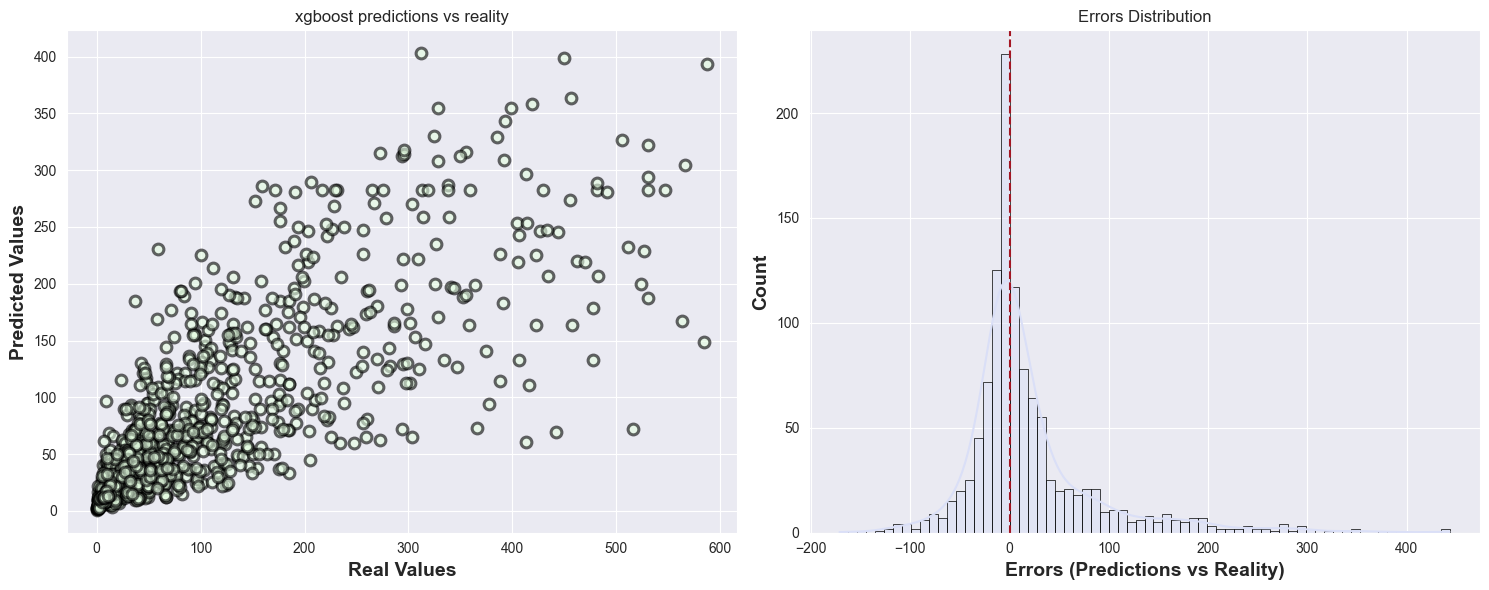

In [402]:
plot_residuals(y_true=y_train2_f,
               y_pred=y_pred_train3_filtered,
               model_name='xgboost')

In [403]:
# Sur l'ensemble de test.
y_pred_test3_filtered = best_xgboost_model3.predict(X_test2_f)

In [404]:
print_metrics(metrics=evaluate_regression(y_true=y_test2_f,
                                          y_pred=y_pred_test3_filtered,
                                          model_name='xgboost'))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 92.87
  MAE  (Mean Absolute Error)     : 55.44
  MAPE (Error %)           : 110.27%
  R²   (Score explication)  : 0.3954


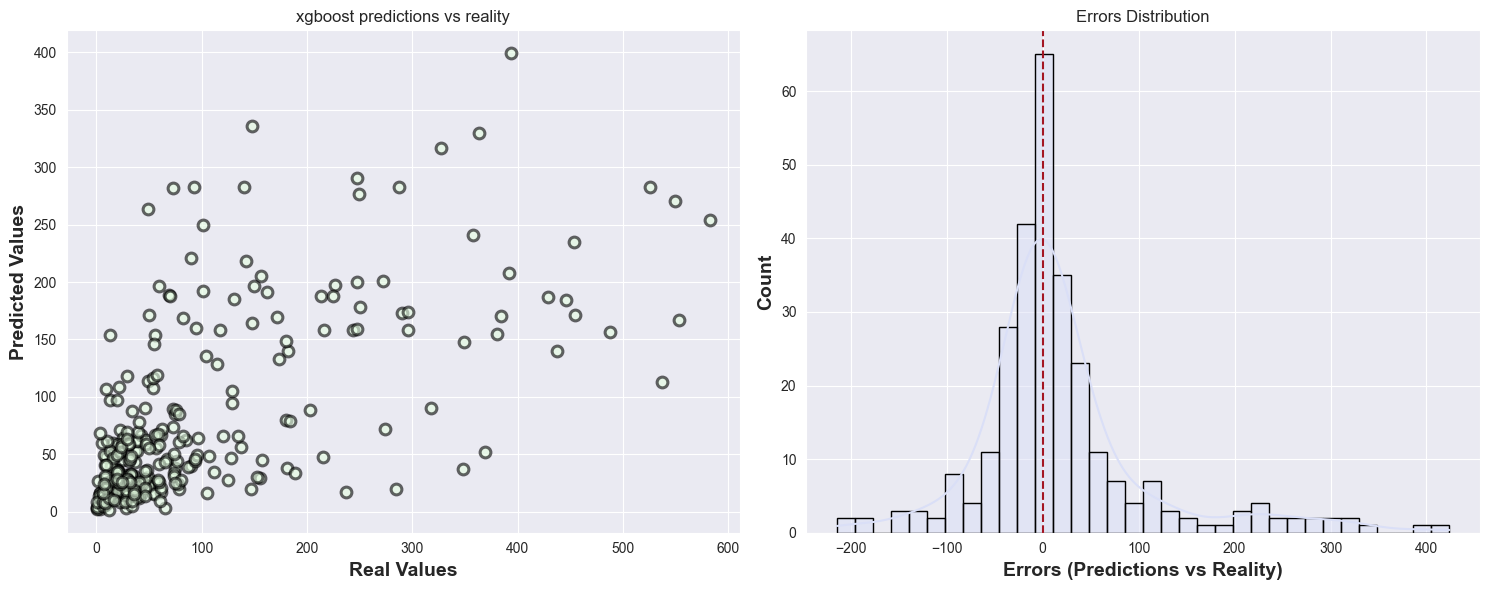

In [405]:
plot_residuals(y_true=y_test2_f, y_pred=y_pred_test3_filtered, model_name='xgboost')

# trial of the random forest model

In [406]:
# Initialisation d'un modèle random_forest pour comparaison avec XGBoost.
random_forest_trainer = ModelTrainer(model_type='random_forest')

In [407]:
base_model_forest = random_forest_trainer.build_pipeline(use_log_target=True)

2026-02-19 00:12:28 | INFO     | energy_sights.modeling.train - Model configuration with a logarithm transformation of the target .
2026-02-19 00:12:28.345 | INFO     | energy_sights.modeling.train:build_pipeline:85 - Model configuration with a logarithm transformation of the target .


In [408]:
# Optimisation des hyperparametres pour sélectionner le meilleur modèle.
best_forest_model1 = tune_model(model=base_model_forest,
                                X_train=X_train2,
                                y_train=y_train2.squeeze(),
                                model_type='random_forest',
                                n_iter=25)

2026-02-19 00:12:28 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-19 00:12:28.506166
2026-02-19 00:12:28.506 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-19 00:12:28.506166
2026-02-19 00:12:28 | INFO     | energy_sights.modeling.tuning - Start of the training for random_forest
2026-02-19 00:12:28.510 | INFO     | energy_sights.modeling.tuning:tune_model:62 - Start of the training for random_forest
Fitting 5 folds for each of 25 candidates, totalling 125 fits
The best parameters finds are: {'regressor__model__n_estimators': 200, 'regressor__model__min_samples_split': 10, 'regressor__model__min_samples_leaf': 8, 'regressor__model__max_features': 0.7, 'regressor__model__max_depth': 7, 'regressor__model__bootstrap': True}
The MAE on the train set:  43.70
The MAE on the validation set:  51.39
The best Score (RMSE roughly): 7.17
Gap (Overfitting):  7.69


In [409]:
y_pred_forest_train1 = best_forest_model1.predict(X_train2)

In [410]:
print_metrics(metrics=evaluate_regression(y_true=y_train2,
                                          y_pred=y_pred_forest_train1,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 76.41
  MAE  (Mean Absolute Error)     : 43.71
  MAPE (Error %)           : 83.31%
  R²   (Score explication)  : 0.5246


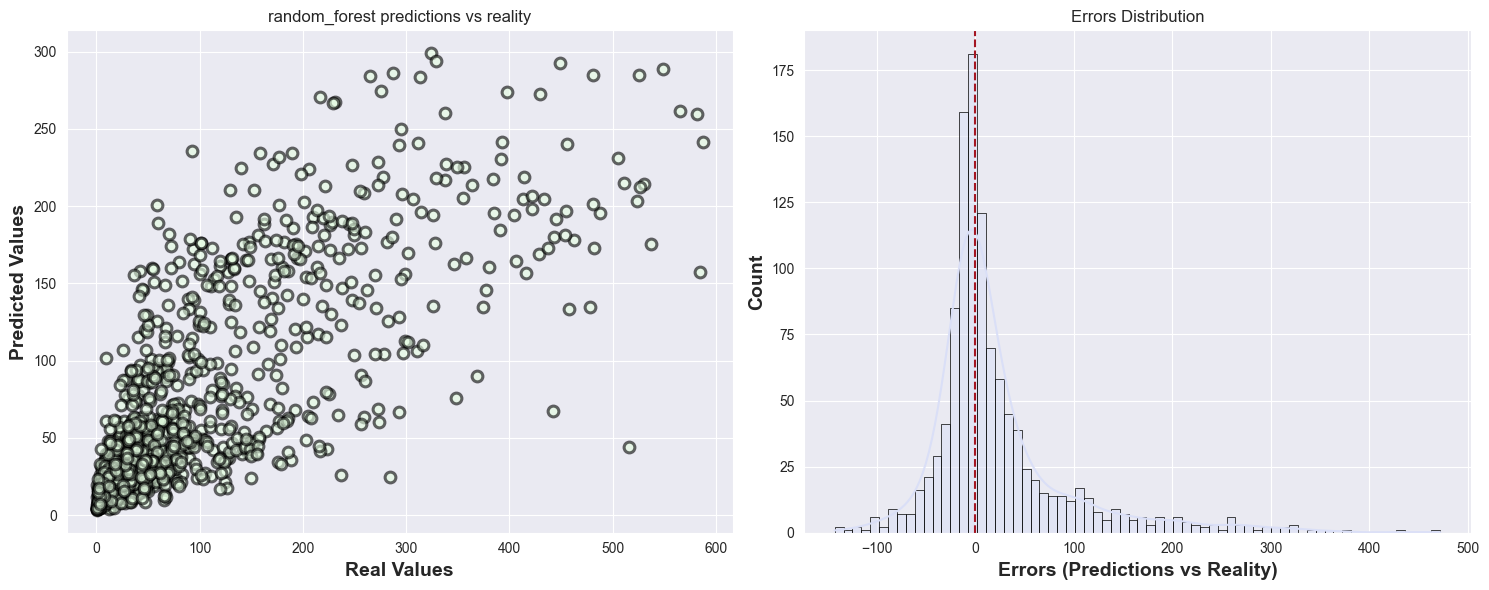

In [411]:
plot_residuals(y_true=y_train2, y_pred=y_pred_forest_train1,
               model_name='random_forest')

In [412]:
# Sur l'ensemble de test.
y_pred_forest_test1 = best_forest_model1.predict(X_test2)

In [413]:
print_metrics(metrics=evaluate_regression(y_true=y_test2, y_pred=y_pred_forest_test1, model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 96.80
  MAE  (Mean Absolute Error)     : 57.81
  MAPE (Error %)           : 113.61%
  R²   (Score explication)  : 0.4544


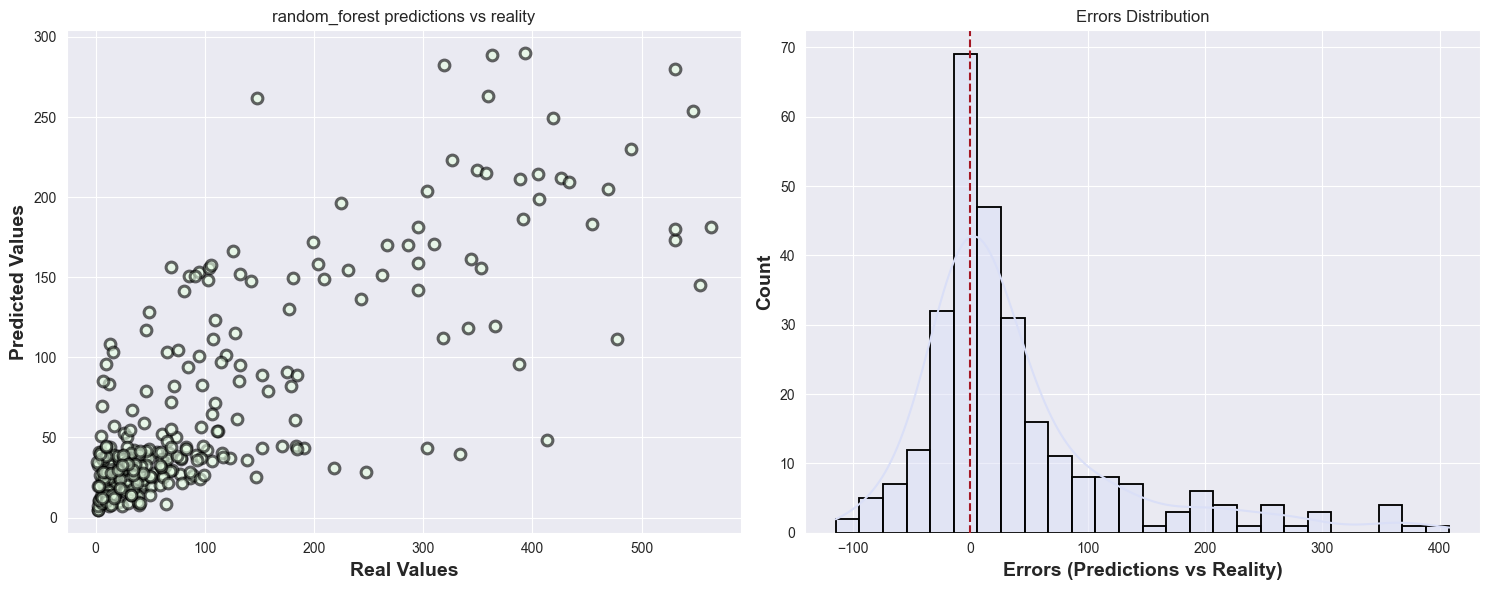

In [414]:
plot_residuals(y_true=y_test2, y_pred=y_pred_forest_test1, model_name='random_forest')

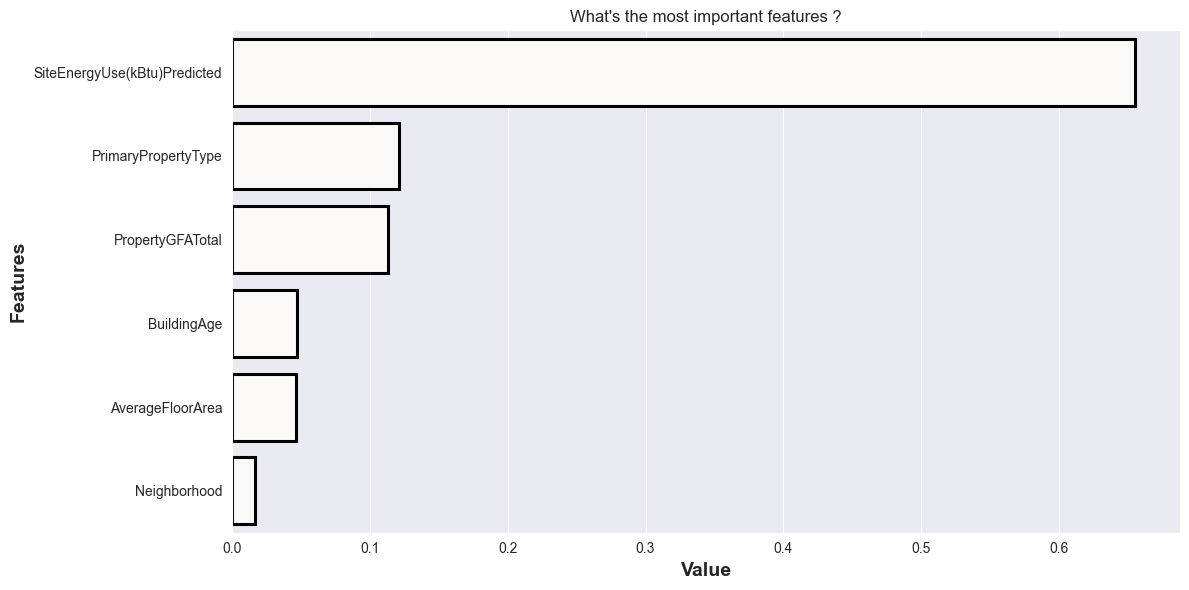

In [415]:
plot_features_importance(model=best_forest_model1, feature_names=X_train2.columns)

In [416]:
print_feature_importances(best_forest_model1, feature_names=X_train2.columns.tolist())

,Features,Values
5,SiteEnergyUse(kBtu)Predicted,0.654881
0,PrimaryPropertyType,0.121193
1,PropertyGFATotal,0.113216
3,BuildingAge,0.047271
4,AverageFloorArea,0.046579
2,Neighborhood,0.016860


In [417]:
# Evaluation du modèle random_forest sur les donnees de reference.
best_forest_model = tune_model(model=base_model_forest,
                               model_type='random_forest',
                               X_train=X_train2,
                               y_train=y_train2.squeeze(),
                               n_iter=20)

2026-02-19 00:13:21 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-19 00:13:21.081131
2026-02-19 00:13:21.081 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-19 00:13:21.081131
2026-02-19 00:13:21 | INFO     | energy_sights.modeling.tuning - Start of the training for random_forest
2026-02-19 00:13:21.086 | INFO     | energy_sights.modeling.tuning:tune_model:62 - Start of the training for random_forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters finds are: {'regressor__model__n_estimators': 200, 'regressor__model__min_samples_split': 10, 'regressor__model__min_samples_leaf': 8, 'regressor__model__max_features': 0.7, 'regressor__model__max_depth': 7, 'regressor__model__bootstrap': True}
The MAE on the train set:  43.70
The MAE on the validation set:  51.39
The best Score (RMSE roughly): 7.17
Gap (Overfitting):  7.69


In [418]:
# Predictions sur l'ensemble d'entrainement.
y_pred_train = best_forest_model.predict(X_train2)

In [419]:
print_metrics(metrics=evaluate_regression(y_true=y_train2,
                                          y_pred=y_pred_train,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 76.41
  MAE  (Mean Absolute Error)     : 43.71
  MAPE (Error %)           : 83.31%
  R²   (Score explication)  : 0.5246


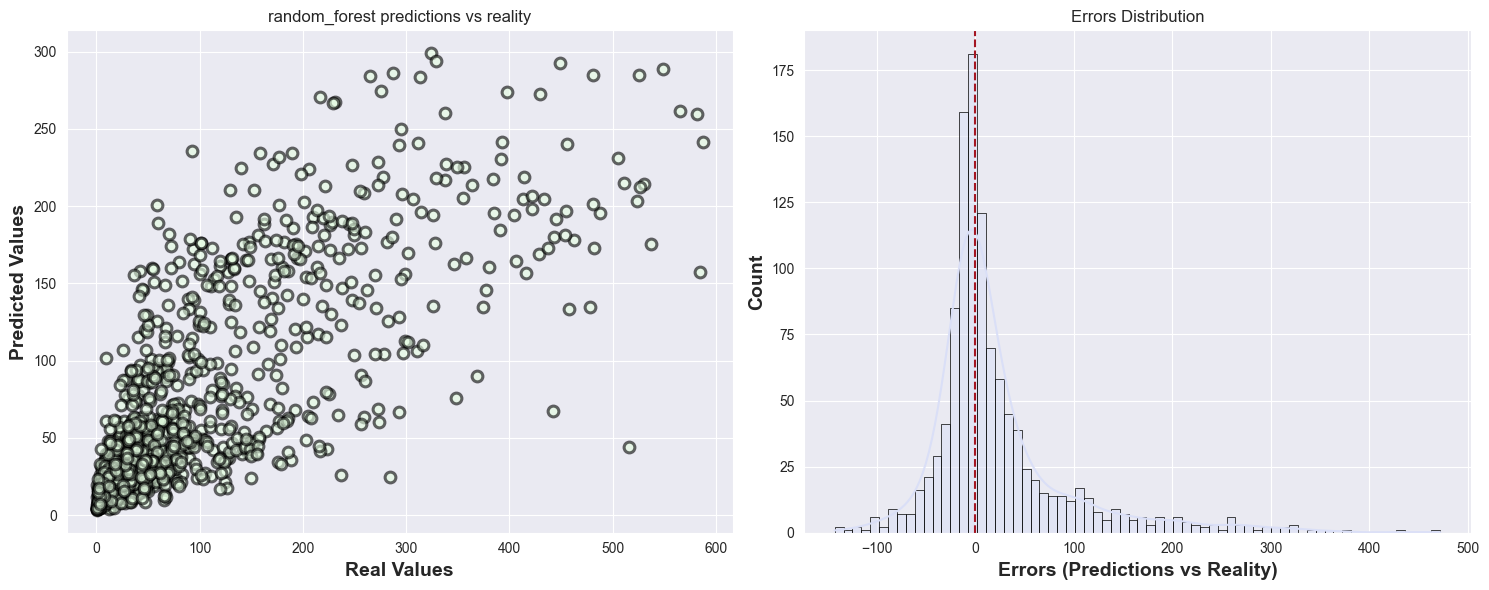

In [420]:
plot_residuals(y_true=y_train2, y_pred=y_pred_train,model_name='random_forest')

In [421]:
# Predictions sur l'ensemble de test.
y_pred_test = best_forest_model.predict(X_test2)

In [422]:
print_metrics(evaluate_regression(y_true=y_test2, y_pred=y_pred_test, model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 96.80
  MAE  (Mean Absolute Error)     : 57.81
  MAPE (Error %)           : 113.61%
  R²   (Score explication)  : 0.4544


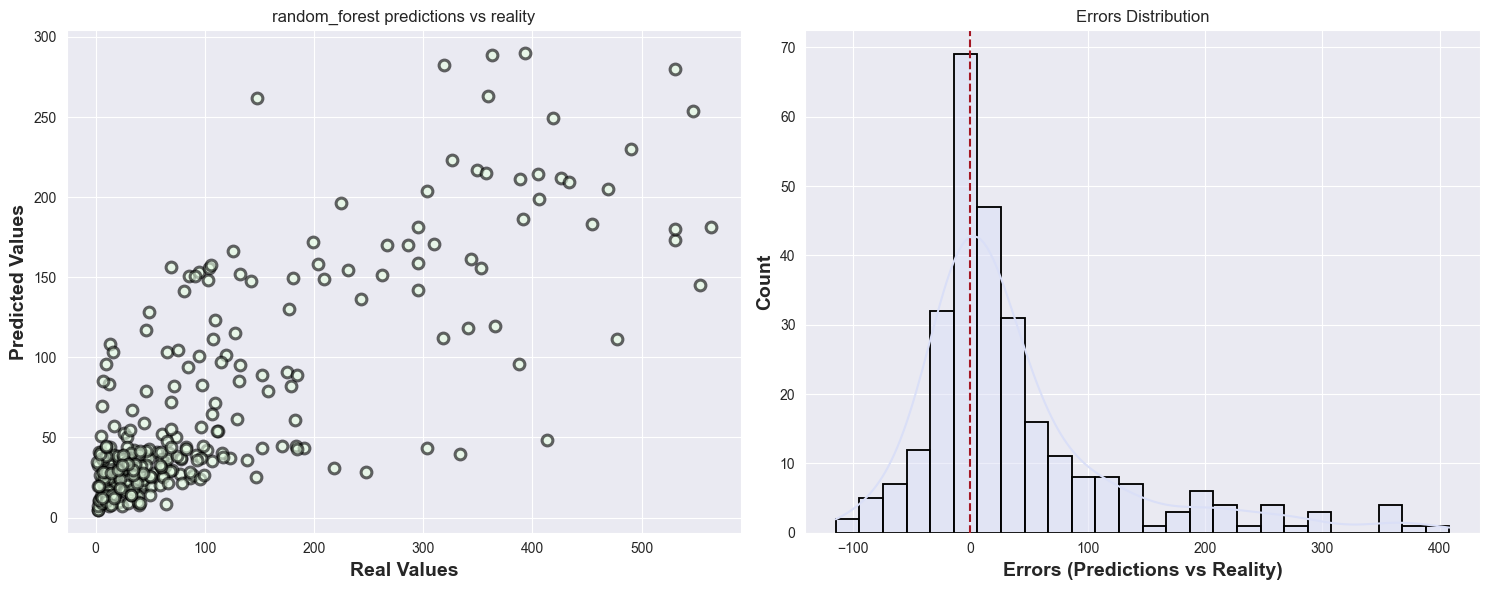

In [423]:
plot_residuals(y_true=y_test2, y_pred=y_pred_test, model_name='random_forest')

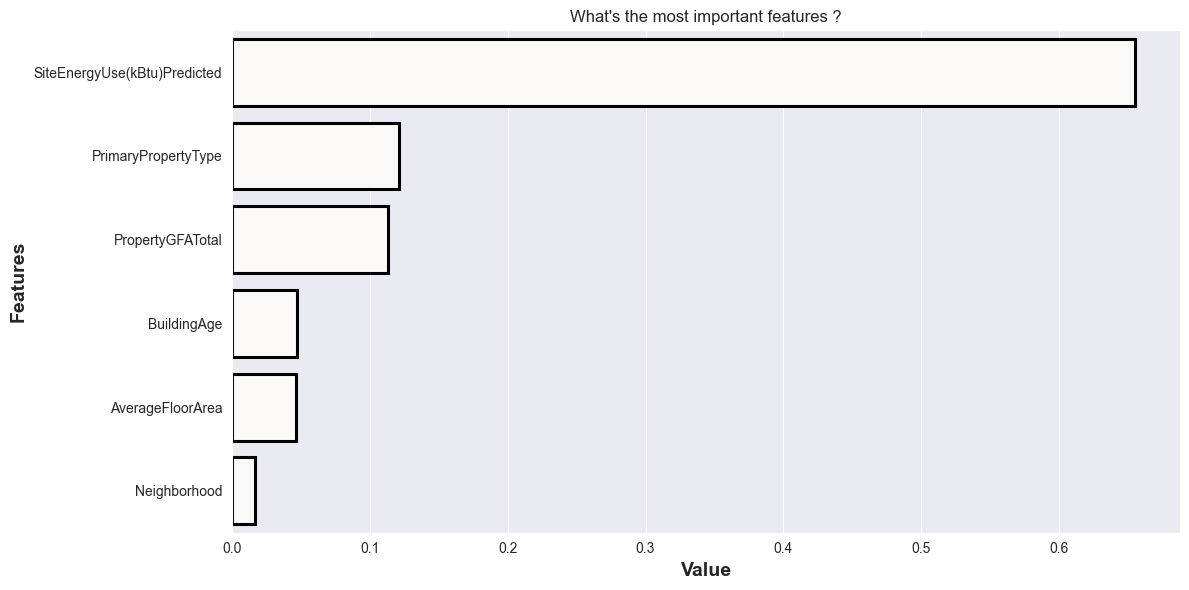

In [424]:
# Identification des variables les plus importantes.
plot_features_importance(model=best_forest_model, feature_names=X_train2.columns.tolist())

In [425]:
# # Sauvegarde du modèle.
# random_forest_trainer.model = best_forest_model
# random_forest_trainer.save_model(model_name='co2_model.pkl')